# Trabajo 01 — Parte 1: Funciones de Prueba y Descenso por Gradiente

**Curso:** Optimización | **Profesor:** Juan David Ospina Arango  
**Entrega:** 24 de marzo de 2026

En este notebook se estudian dos funciones clásicas de prueba para optimización y se aplica el método de **descenso por gradiente** con búsqueda de línea por retroceso (*backtracking line search*) en 2D y 3D.

| # | Sección | Contenido |
|---|---|---|
| 1 | Funciones de prueba | Definición matemática, gradientes analíticos, verificación |
| 2 | Visualización | Contour plots 2D y superficies 3D |
| 3 | Descenso por gradiente | Implementación con backtracking, resultados 2D y 3D |
| 4 | Animaciones | GIFs del proceso de convergencia |
| 5 | Conclusiones | Hallazgos clave |

In [1]:
# Descomentar si se ejecuta en Google Colab
# !pip install numpy matplotlib pillow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path
from IPython.display import Image, display

# --- Constantes globales ---
SEED        = 42
BOUNDS_2D   = (-3.0, 3.0)   # dominio de visualización
BOUNDS_OPT  = (-5.0, 5.0)   # dominio de optimización
GRID_N      = 300            # resolución del grid de contour
A_RASTRIGIN = 10             # parámetro A de la función de Rastrigin
GIF_FPS     = 20
GIF_FRAMES  = 150

# Parámetros del descenso por gradiente
GD_ALPHA0   = 1.0
GD_RHO      = 0.5
GD_C_ARMIJO = 1e-4
GD_TOL      = 1e-6
GD_MAX_ITER = 2_000
H_GRAD      = 1e-5      # paso del gradiente numerico (dif. centrales)

np.random.seed(SEED)
Path('outputs').mkdir(exist_ok=True)
print('Entorno listo.')

Entorno listo.


## 1. Funciones de prueba

Se seleccionaron dos funciones ampliamente usadas como *benchmarks* en optimización global:

### 1.1 Función de Rosenbrock

$$f(\mathbf{x}) = \sum_{i=1}^{n-1} \left[ 100\,(x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$$

- **Mínimo global:** $f(1, 1, \ldots, 1) = 0$
- **Dificultad:** el mínimo yace en el fondo de un valle estrecho y curvado; el gradiente apunta casi perpendicular a la dirección de menor valor.

### 1.2 Función de Rastrigin

$$f(\mathbf{x}) = An + \sum_{i=1}^{n} \left[ x_i^2 - A\cos(2\pi x_i) \right], \quad A = 10$$

- **Mínimo global:** $f(0, 0, \ldots, 0) = 0$
- **Dificultad:** altamente multimodal — contiene $O(10^n)$ mínimos locales en cuadrícula regular, lo que atrapa al gradiente con facilidad.

In [3]:
def rosenbrock(x):
    """Rosenbrock: mínimo global en x=[1,...,1], f=0."""
    x = np.asarray(x, dtype=float)
    return float(np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1.0 - x[:-1])**2))

def grad_rosenbrock(x):
    """Gradiente analítico de Rosenbrock."""
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    g[:-1] += -400.0 * x[:-1] * (x[1:] - x[:-1]**2) - 2.0 * (1.0 - x[:-1])
    g[1:]  +=  200.0 * (x[1:] - x[:-1]**2)
    return g

def rastrigin(x):
    """Rastrigin: mínimo global en x=[0,...,0], f=0."""
    x = np.asarray(x, dtype=float)
    return float(A_RASTRIGIN * len(x) + np.sum(x**2 - A_RASTRIGIN * np.cos(2*np.pi*x)))

def grad_rastrigin(x):
    """Gradiente analítico de Rastrigin."""
    x = np.asarray(x, dtype=float)
    return 2.0 * x + 2.0 * np.pi * A_RASTRIGIN * np.sin(2*np.pi*x)

# Verificación en el mínimo conocido
assert abs(rosenbrock([1.0, 1.0])) < 1e-10
assert abs(rosenbrock([1.0, 1.0, 1.0])) < 1e-10
assert abs(rastrigin([0.0, 0.0])) < 1e-10
assert abs(rastrigin([0.0, 0.0, 0.0])) < 1e-10
print('Verificación OK — ambas funciones evaluadas correctamente en sus mínimos.')

Verificación OK — ambas funciones evaluadas correctamente en sus mínimos.


### 1.2 Funciones adicionales

La tarea requiere seis funciones en total. Se agregan las cuatro restantes:

| Funcion | Dominio | Minimo global | Dimensiones |
|---|---|---|---|
| **Schwefel** | $[-500, 500]^n$ | $f(420.97,\ldots) = 0$ | 2D y 3D |
| **Griewank** | $[-600, 600]^n$ | $f(0,\ldots,0) = 0$ | 2D y 3D |
| **Goldstein-Price** | $[-2, 2]^2$ | $f(0,-1) = 3$ | Solo 2D |
| **Camel 6-hump** | $x_1\in[-3,3],\, x_2\in[-2,2]$ | $f(\pm0.0898, \mp0.7126)\approx -1.0316$ | Solo 2D |

> Goldstein-Price y Camel son funciones **exclusivamente bidimensionales**.
> Schwefel y Griewank se extienden a 3D de forma natural.

In [4]:
# ---------------------------------------------------------------------------
# Funciones adicionales requeridas por la tarea
# Cada funcion incluye su formula, dominio y minimo global conocido.
# ---------------------------------------------------------------------------

def schwefel(x):
    """
    Funcion de Schwefel.
    Dominio: x_i en [-500, 500].
    Minimo global: f(420.9687, ...) = 0.
    Nota: el minimo esta lejos del centro del dominio, lo que engana facilmente al GD.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    return float(418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x)))))


def grad_schwefel(x):
    """Gradiente de Schwefel por diferencias finitas centradas."""
    return gradiente_numerico(schwefel, x)


def griewank(x):
    """
    Funcion de Griewank.
    Dominio: x_i en [-600, 600].
    Minimo global: f(0, ..., 0) = 0.
    Nota: tiene muchos minimos locales uniformemente distribuidos.
    """
    x = np.asarray(x, dtype=float)
    suma = np.sum(x**2) / 4000
    prod = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return float(1 + suma - prod)


def grad_griewank(x):
    """Gradiente de Griewank por diferencias finitas centradas."""
    return gradiente_numerico(griewank, x)


def goldstein_price(x):
    """
    Funcion de Goldstein-Price (solo 2D).
    Dominio: x_i en [-2, 2].
    Minimo global: f(0, -1) = 3.
    Nota: paisaje muy irregular, multiple minimos locales.
    """
    x = np.asarray(x, dtype=float)
    x1, x2 = float(x[0]), float(x[1])
    a = (1 + (x1 + x2 + 1)**2
         * (19 - 14*x1 + 3*x1**2 - 14*x2 + 6*x1*x2 + 3*x2**2))
    b = (30 + (2*x1 - 3*x2)**2
         * (18 - 32*x1 + 12*x1**2 + 48*x2 - 36*x1*x2 + 27*x2**2))
    return float(a * b)


def grad_goldstein_price(x):
    """Gradiente de Goldstein-Price por diferencias finitas centradas."""
    return gradiente_numerico(goldstein_price, x)


def camel_6hump(x):
    """
    Funcion de las seis jorobas de camello (Six-Hump Camel), solo 2D.
    Dominio: x1 en [-3, 3], x2 en [-2, 2].
    Minimos globales: f(0.0898, -0.7126) = f(-0.0898, 0.7126) ~ -1.0316.
    Nota: dos minimos globales simetricos, seis jorobas locales.
    """
    x = np.asarray(x, dtype=float)
    x1, x2 = float(x[0]), float(x[1])
    return float(
        (4 - 2.1*x1**2 + x1**4 / 3) * x1**2
        + x1 * x2
        + (-4 + 4*x2**2) * x2**2
    )


def grad_camel_6hump(x):
    """Gradiente de Camel 6-hump por diferencias finitas centradas."""
    return gradiente_numerico(camel_6hump, x)


# ---------------------------------------------------------------------------
# Verificacion en los minimos conocidos
# ---------------------------------------------------------------------------
print("Verificacion de nuevas funciones en sus minimos globales:")
print(f"  Schwefel       [420.97, 420.97] -> f = {schwefel([420.9687, 420.9687]):.4f}  (esperado ~ 0)")
print(f"  Griewank       [0, 0]           -> f = {griewank([0.0, 0.0]):.4f}             (esperado = 0)")
print(f"  Goldstein      [0, -1]          -> f = {goldstein_price([0.0, -1.0]):.4f}     (esperado = 3)")
print(f"  Camel 6-hump   [0.0898,-0.7126] -> f = {camel_6hump([0.0898, -0.7126]):.4f}  (esperado ~ -1.0316)")

Verificacion de nuevas funciones en sus minimos globales:
  Schwefel       [420.97, 420.97] -> f = 0.0000  (esperado ~ 0)
  Griewank       [0, 0]           -> f = 0.0000             (esperado = 0)
  Goldstein      [0, -1]          -> f = 3.0000     (esperado = 3)
  Camel 6-hump   [0.0898,-0.7126] -> f = -1.0316  (esperado ~ -1.0316)


### 1.3 Verificación de gradientes por diferencias finitas

Se compara el gradiente analítico contra la aproximación numérica centrada:

$$\frac{\partial f}{\partial x_i} \approx \frac{f(x + \varepsilon e_i) - f(x - \varepsilon e_i)}{2\varepsilon}, \quad \varepsilon = 10^{-5}$$

In [5]:
def gradiente_numerico(f, x, eps=1e-5):
    """Gradiente por diferencias finitas centradas."""
    g = np.zeros_like(x)
    for i in range(len(x)):
        xp, xm = x.copy(), x.copy()
        xp[i] += eps
        xm[i] -= eps
        g[i] = (f(xp) - f(xm)) / (2 * eps)
    return g

x_test = np.random.uniform(-2, 2, 3)
for nombre, f, gf in [('Rosenbrock', rosenbrock, grad_rosenbrock),
                       ('Rastrigin',  rastrigin,  grad_rastrigin)]:
    error = np.max(np.abs(gf(x_test) - gradiente_numerico(f, x_test)))
    print(f'{nombre}: error máx. gradiente = {error:.2e}  {"OK" if error < 1e-4 else "FALLA"}')

Rosenbrock: error máx. gradiente = 8.71e-08  OK
Rastrigin: error máx. gradiente = 3.86e-08  OK


## 2. Visualización 2D y 3D

Se generan contour plots (vista cenital) y superficies 3D para entender la geometría antes de optimizar.
Se aplica $\log(1 + f)$ al contour para mejorar el contraste en regiones con valores muy distintos.

Los grids se calculan **una sola vez** y se reutilizan en todas las visualizaciones y animaciones.

In [6]:
# ---------------------------------------------------------------------------
# Lista canonica de funciones usada en todo el notebook.
# Se distingue entre funciones validas en nD y las que son solo 2D.
# ---------------------------------------------------------------------------

# Funciones validas en 2D y 3D
CONFIGS_ND = [
    ('Rosenbrock', rosenbrock,       grad_rosenbrock),
    ('Rastrigin',  rastrigin,        grad_rastrigin),
    ('Schwefel',   schwefel,         grad_schwefel),
    ('Griewank',   griewank,         grad_griewank),
]

# Funciones exclusivamente 2D por definicion matematica
CONFIGS_2D_ONLY = [
    ('Goldstein-Price', goldstein_price,  grad_goldstein_price),
    ('Camel 6-hump',    camel_6hump,      grad_camel_6hump),
]

# CONFIGS: todas las funciones (para visualizacion y GD en 2D)
CONFIGS = CONFIGS_ND + CONFIGS_2D_ONLY

# Dominio de visualizacion por funcion (cada una en su propio dominio)
GRID_BOUNDS = {
    'Rosenbrock': (-5.0, 5.0), 'Rastrigin': (-5.0, 5.0),
    'Schwefel': (-500.0, 500.0), 'Griewank': (-600.0, 600.0),
    'Goldstein-Price': (-2.0, 2.0), 'Camel 6-hump': (-3.0, 3.0),
}


def make_grid(f, bounds, n=GRID_N):
    """Evalua f en un grid 2D para visualizacion."""
    x  = np.linspace(*bounds, n)
    X, Y = np.meshgrid(x, x)
    XY = np.stack([X, Y], axis=-1)
    Z  = np.apply_along_axis(f, 2, XY)
    return X, Y, Z


# Pre-calcular grids una sola vez, cada funcion en su dominio
grids = {nombre: make_grid(f, GRID_BOUNDS[nombre]) for nombre, f, _ in CONFIGS}
print("Funciones registradas:", [c[0] for c in CONFIGS])
print("Grids calculados:", list(grids.keys()))

Funciones registradas: ['Rosenbrock', 'Rastrigin', 'Schwefel', 'Griewank', 'Goldstein-Price', 'Camel 6-hump']
Grids calculados: ['Rosenbrock', 'Rastrigin', 'Schwefel', 'Griewank', 'Goldstein-Price', 'Camel 6-hump']


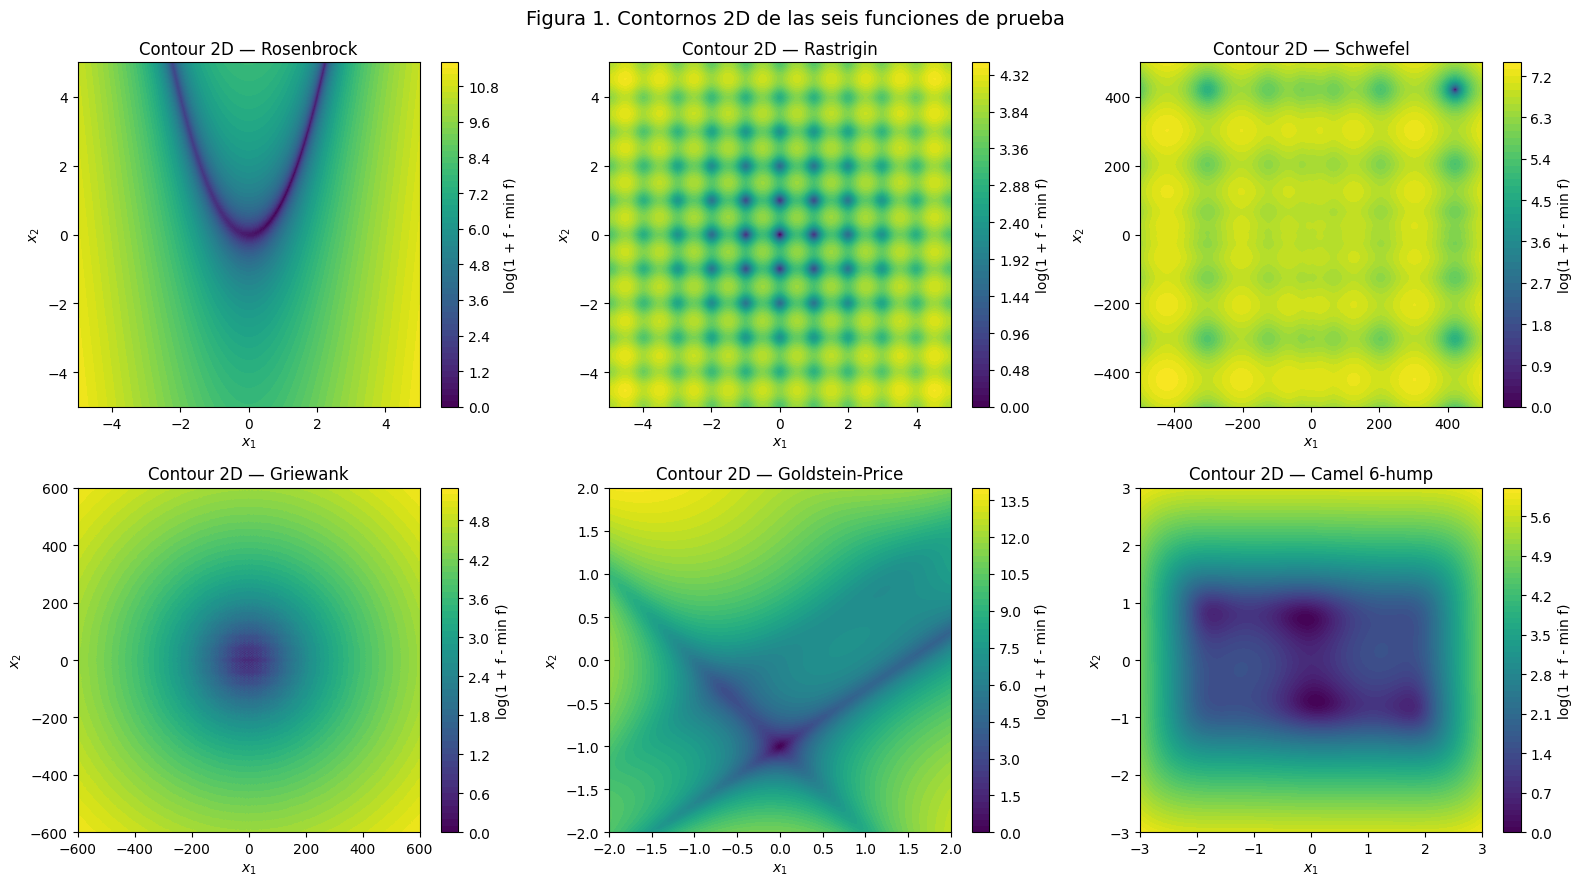

Guardado: outputs/contour_2d.png


In [7]:
# Contour 2D de las seis funciones (escala log desplazada para incluir valores
# negativos, p. ej. Camel 6-hump). Cada funcion en su propio dominio.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, (nombre, f, _) in enumerate(CONFIGS):
    ax = axes.flat[i]
    X, Y, Z = grids[nombre]
    cp = ax.contourf(X, Y, np.log1p(Z - Z.min()), levels=60, cmap='viridis')
    fig.colorbar(cp, ax=ax, label='log(1 + f - min f)')
    ax.set_title(f'Contour 2D — {nombre}')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

fig.suptitle('Figura 1. Contornos 2D de las seis funciones de prueba', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/contour_2d.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: outputs/contour_2d.png')

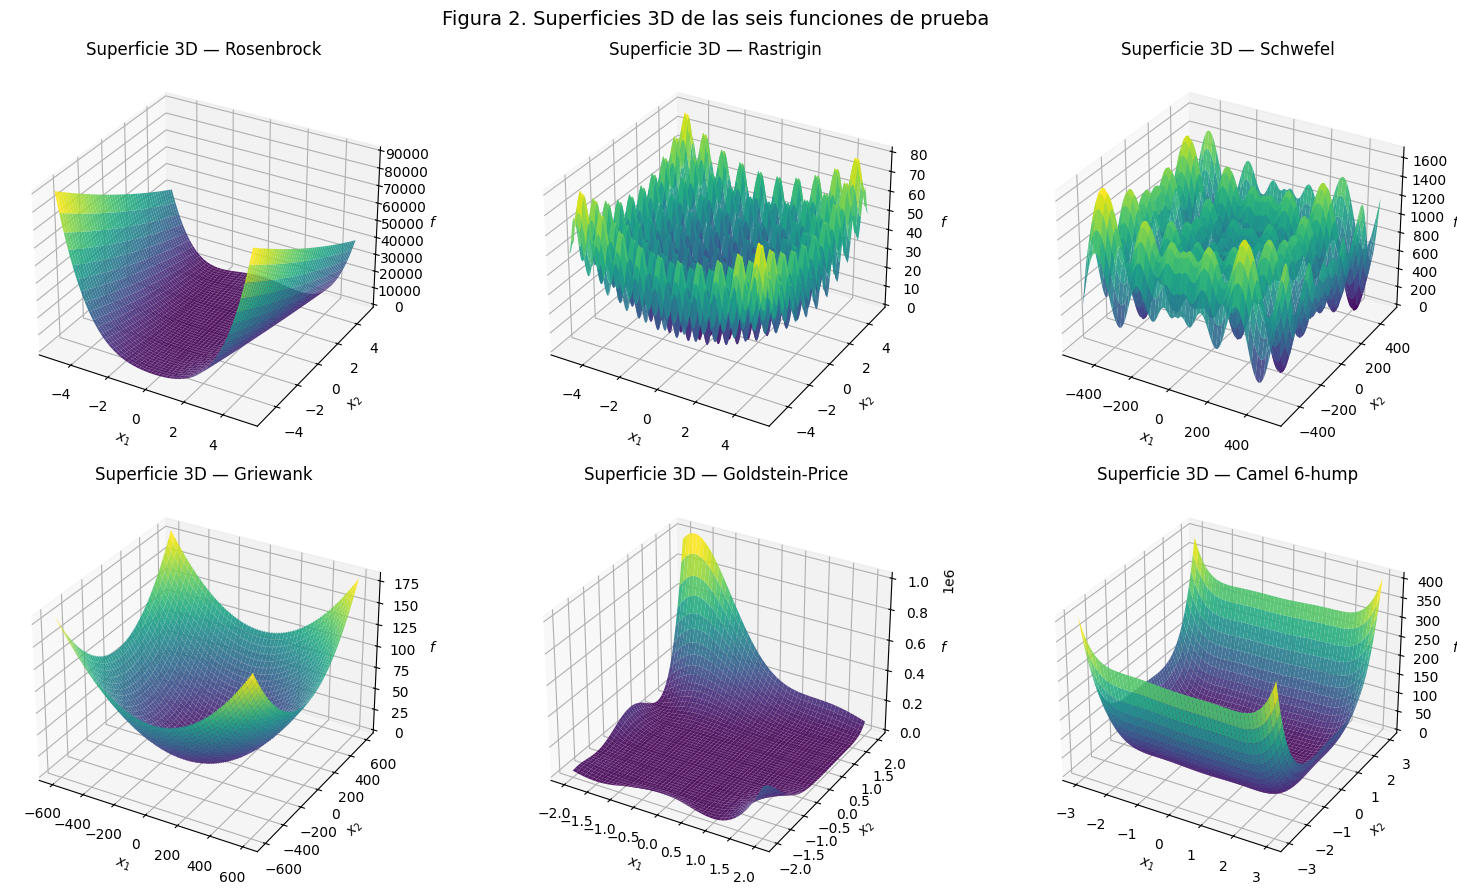

Guardado: outputs/superficie_3d.png


In [8]:
# Superficies 3D de las seis funciones de prueba.
fig = plt.figure(figsize=(16, 9))

for i, (nombre, f, _) in enumerate(CONFIGS):
    X, Y, Z = grids[nombre]
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)
    ax.set_title(f'Superficie 3D — {nombre}')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$f$')

fig.suptitle('Figura 2. Superficies 3D de las seis funciones de prueba', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/superficie_3d.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: outputs/superficie_3d.png')

## 3. Descenso por gradiente

### 3.1 Algoritmo

Se implementa el descenso por gradiente con **búsqueda de línea por retroceso** (*backtracking line search*), que satisface la condición de Armijo:

$$f(\mathbf{x} + \alpha \mathbf{d}) \leq f(\mathbf{x}) + c \cdot \alpha \cdot \nabla f(\mathbf{x})^\top \mathbf{d}$$

donde $\mathbf{d} = -\nabla f(\mathbf{x})$ es la dirección de descenso, $\alpha$ se reduce por el factor $\rho$ hasta satisfacer la condición.

**Parámetros:** $\alpha_0 = 1.0$, $\rho = 0.5$, $c = 10^{-4}$, tolerancia $\|\nabla f\| < 10^{-6}$, máx. 10 000 iteraciones.

In [9]:
# Dominio de optimizacion por funcion (caja [lo, hi]); el GD se proyecta a el.
BOUNDS_OPT_FUNC = {
    'Rosenbrock': (-5.0, 5.0), 'Rastrigin': (-5.0, 5.0),
    'Schwefel': (-500.0, 500.0), 'Griewank': (-600.0, 600.0),
    'Goldstein-Price': (-2.0, 2.0), 'Camel 6-hump': (-3.0, 3.0),
}


def _grad_numerico(f, x, h=H_GRAD):
    """Gradiente por diferencias centrales. Devuelve (g, n_evals_usadas)."""
    g  = np.empty_like(x)
    ne = 0
    for i in range(x.size):
        xp = x.copy(); xp[i] += h
        xm = x.copy(); xm[i] -= h
        g[i] = (f(xp) - f(xm)) / (2.0 * h)
        ne  += 2
    return g, ne


def descenso_gradiente(f, x0, lo, hi):
    """
    Descenso por gradiente PROYECTADO al dominio [lo, hi], con gradiente numerico
    (dif. centrales, h=1e-5) y busqueda de linea por retroceso (Armijo).

    Se recorta cada iterado a la caja: sin proyeccion el GD se escapa del dominio
    en funciones como Schwefel y reporta valores por debajo del optimo global.
    Cuenta TODAS las evaluaciones de f (gradiente + backtracking).

    Retorna: x_final, f_final, n_iter, n_evals, trayectoria, historial_f.
    """
    x           = np.clip(np.array(x0, dtype=float), lo, hi)
    fx          = f(x)
    n_evals     = 1
    trayectoria = [x.copy()]
    historial_f = [fx]

    it = 0
    for it in range(GD_MAX_ITER):
        g, ne = _grad_numerico(f, x)
        n_evals += ne
        gnorm = np.linalg.norm(g)
        if gnorm < GD_TOL:                  # 1) gradiente ~ 0
            break
        direccion = -g
        gx_dir    = -gnorm ** 2
        alpha     = GD_ALPHA0
        mejorado  = False
        while alpha >= 1e-14:               # backtracking (Armijo)
            x_new  = np.clip(x + alpha * direccion, lo, hi)   # proyeccion al dominio
            fx_new = f(x_new)
            n_evals += 1
            if fx_new <= fx + GD_C_ARMIJO * alpha * gx_dir:
                mejorado = True
                break
            alpha *= GD_RHO
        if not mejorado:                    # 2) la busqueda de linea no avanza
            break
        estanca = (fx - fx_new) < 1e-10 * (1.0 + abs(fx))
        x, fx = x_new, fx_new
        trayectoria.append(x.copy())
        historial_f.append(fx)
        if estanca:                         # 3) estancamiento
            break

    return {
        'x_final':     x,
        'f_final':     float(fx),
        'n_iter':      it + 1,
        'n_evals':     n_evals,
        'trayectoria': np.array(trayectoria),
        'historial_f': historial_f,
    }


# Demostracion en Rosenbrock 2D
_lo, _hi = BOUNDS_OPT_FUNC['Rosenbrock']
res_demo = descenso_gradiente(rosenbrock, np.array([-2.0, 2.0]), _lo, _hi)
print(f'GD | Rosenbrock 2D | f* = {res_demo["f_final"]:.4e} | '
      f'iter = {res_demo["n_iter"]} | evals = {res_demo["n_evals"]}')

GD | Rosenbrock 2D | f* = 1.0316e-01 | iter = 2000 | evals = 29493


### 3.2 Resultados en 2D y 3D

Condición inicial aleatoria uniforme en $[-5, 5]^n$ para cada combinación de función y dimensión.

In [10]:
resultados_gd = {}
print(f'{"Funcion":<12} {"Dim":>4} {"f*":>12} {"Iteraciones":>12} {"Evaluaciones":>13}')
print('-' * 56)

SOLO_2D = {'Goldstein-Price', 'Camel 6-hump'}

for nombre, f, gf in CONFIGS:
    resultados_gd[nombre] = {}
    lo, hi = BOUNDS_OPT_FUNC[nombre]
    dims = [2] if nombre in SOLO_2D else [2, 3]
    for ndim in dims:
        x0  = np.random.uniform(lo, hi, ndim)
        res = descenso_gradiente(f, x0, lo, hi)
        resultados_gd[nombre][ndim] = res
        print(f'{nombre:<12} {ndim:>4} {res["f_final"]:>12.4e} '
              f'{res["n_iter"]:>12} {res["n_evals"]:>13}')

Funcion       Dim           f*  Iteraciones  Evaluaciones
--------------------------------------------------------
Rosenbrock      2   5.7191e-04         2000         27449
Rosenbrock      3   8.8138e-02         2000         33684
Rastrigin       2   4.9748e+00           19           248
Rastrigin       3   0.0000e+00            3            22


Schwefel        2   2.3688e+02           37           186
Schwefel        3   8.2958e+02           45           316
Griewank        2   1.7127e+01           16            81
Griewank        3   6.6583e+01           23           162
Goldstein-Price    2   3.0000e+01           16           259
Camel 6-hump    2  -1.0316e+00           10            81


### 3.3 Curvas de convergencia

Se grafica $f$ vs. iteración en escala logarítmica para comparar la velocidad de convergencia en 2D y 3D.

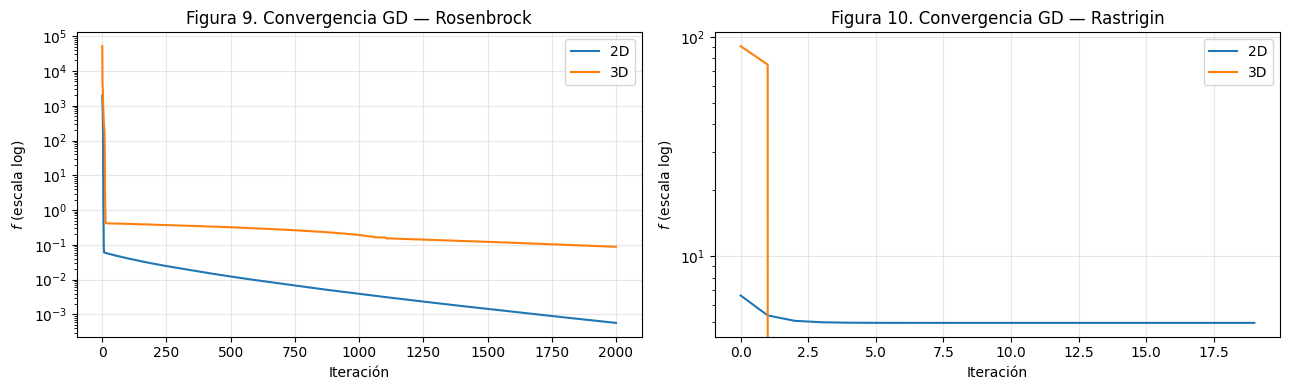

Guardado: outputs/convergencia_gd.png


In [11]:
fig, axes  = plt.subplots(1, 2, figsize=(13, 4))
colores_nd = {2: '#1f77b4', 3: '#ff7f0e'}
fig_offset = len(CONFIGS) + 2   # figuras 1-4 ya usadas

for i, (ax, (nombre, f, gf)) in enumerate(zip(axes, CONFIGS)):
    for ndim in [2, 3]:
        hist = resultados_gd[nombre][ndim]['historial_f']
        ax.semilogy(hist, color=colores_nd[ndim], label=f'{ndim}D')
    ax.set_title(f'Figura {fig_offset + i + 1}. Convergencia GD — {nombre}')
    ax.set_xlabel('Iteración')
    ax.set_ylabel('$f$ (escala log)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/convergencia_gd.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: outputs/convergencia_gd.png')

### 3.4 Analisis estadistico: n = 100, 500 y 1000 condiciones iniciales

Para evaluar la robustez del descenso por gradiente se repite el proceso con
**n condiciones iniciales aleatorias** (n = 100, 500 y 1000).

Se registran dos metricas por corrida:
- **f\*** — valor de la funcion objetivo al converger.
- **Evaluaciones** — numero de evaluaciones de la funcion objetivo hasta la convergencia.

Los histogramas permiten ver si el GD encuentra el minimo global de forma
consistente o queda atrapado en minimos locales segun la funcion.

In [12]:
# ---------------------------------------------------------------------------
# Experimento estadistico (punto 1 del enunciado): n = 100, 500, 1000 condiciones
# iniciales aleatorias por funcion y dimension, con el descenso por gradiente
# PROYECTADO definido arriba. Autocontenido: se calcula aqui y se guarda en la
# variable `resultados_stat` (sin leer ningun archivo), para que funcione tambien
# en Google Colab.
#
# NOTA: tarda varios minutos. Es el costo real de 100/500/1000 corridas por
# configuracion; Rosenbrock domina el tiempo (recorre su valle estrecho hasta el
# tope de iteraciones).
# ---------------------------------------------------------------------------
N_REPS_LIST = [100, 500, 1000]
resultados_stat = {}   # nombre -> ndim -> n_reps -> {'f_vals': [...], 'evals': [...]}

for nombre, f, gf in CONFIGS_ND:
    lo, hi = BOUNDS_OPT_FUNC[nombre]
    resultados_stat[nombre] = {}
    for ndim in (2, 3):
        resultados_stat[nombre][ndim] = {}
        for n_reps in N_REPS_LIST:
            rng = np.random.default_rng(SEED)
            f_vals, evals = [], []
            for _ in range(n_reps):
                res = descenso_gradiente(f, rng.uniform(lo, hi, ndim), lo, hi)
                f_vals.append(res['f_final'])
                evals.append(res['n_evals'])
            resultados_stat[nombre][ndim][n_reps] = {'f_vals': f_vals, 'evals': evals}
    print(f'{nombre}: listo (2D y 3D)')

# Resumen (n = 1000)
print(f'\n{"Funcion":<12}{"Dim":>4}{"media f*":>14}{"mejor f*":>14}{"evals prom":>13}')
print('-' * 57)
for nombre in resultados_stat:
    for ndim in (2, 3):
        dd = resultados_stat[nombre][ndim][1000]
        fa = np.array(dd['f_vals'])
        print(f'{nombre:<12}{ndim:>3}D{fa.mean():>14.3e}{fa.min():>14.3e}{int(np.mean(dd["evals"])):>13}')

Rosenbrock: listo (2D y 3D)


Rastrigin: listo (2D y 3D)


Schwefel: listo (2D y 3D)


Griewank: listo (2D y 3D)

Funcion      Dim      media f*      mejor f*   evals prom
---------------------------------------------------------
Rosenbrock    2D     3.176e-01     6.322e-07        28653
Rosenbrock    3D     6.955e-01     1.032e-05        32664
Rastrigin     2D     3.308e+00     0.000e+00          166
Rastrigin     3D     1.101e+01     0.000e+00          209
Schwefel      2D     3.876e+02     2.546e-05          204
Schwefel      3D     5.851e+02     3.818e-05          283
Griewank      2D     6.059e+01     7.396e-03           86
Griewank      3D     9.042e+01     1.553e-01          224


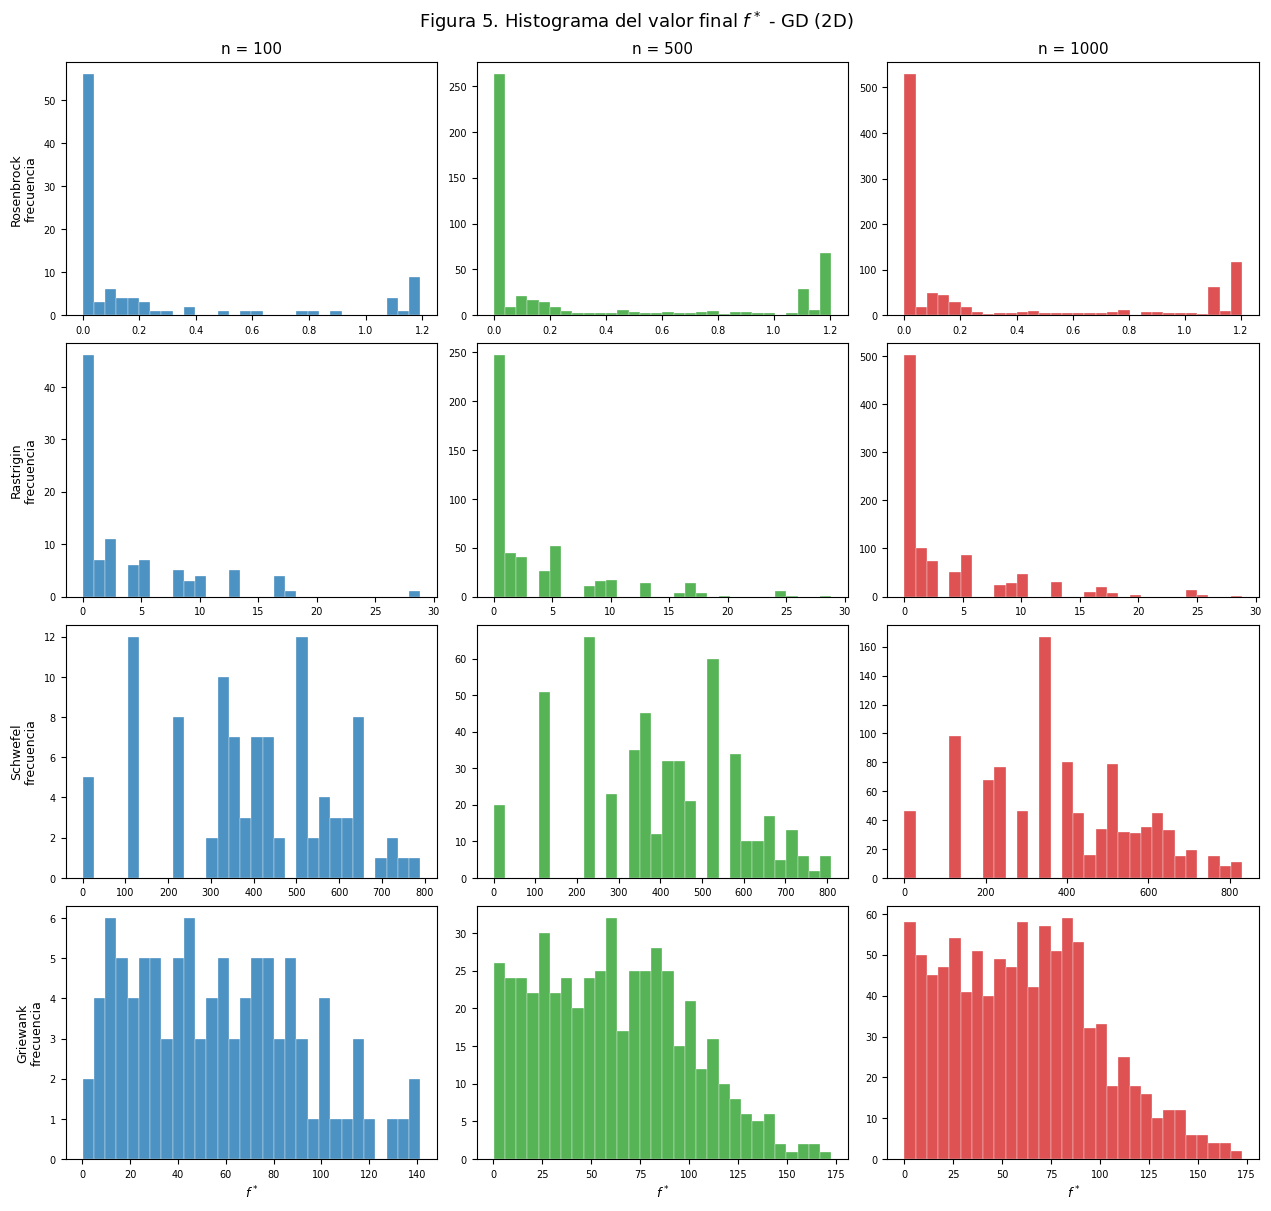

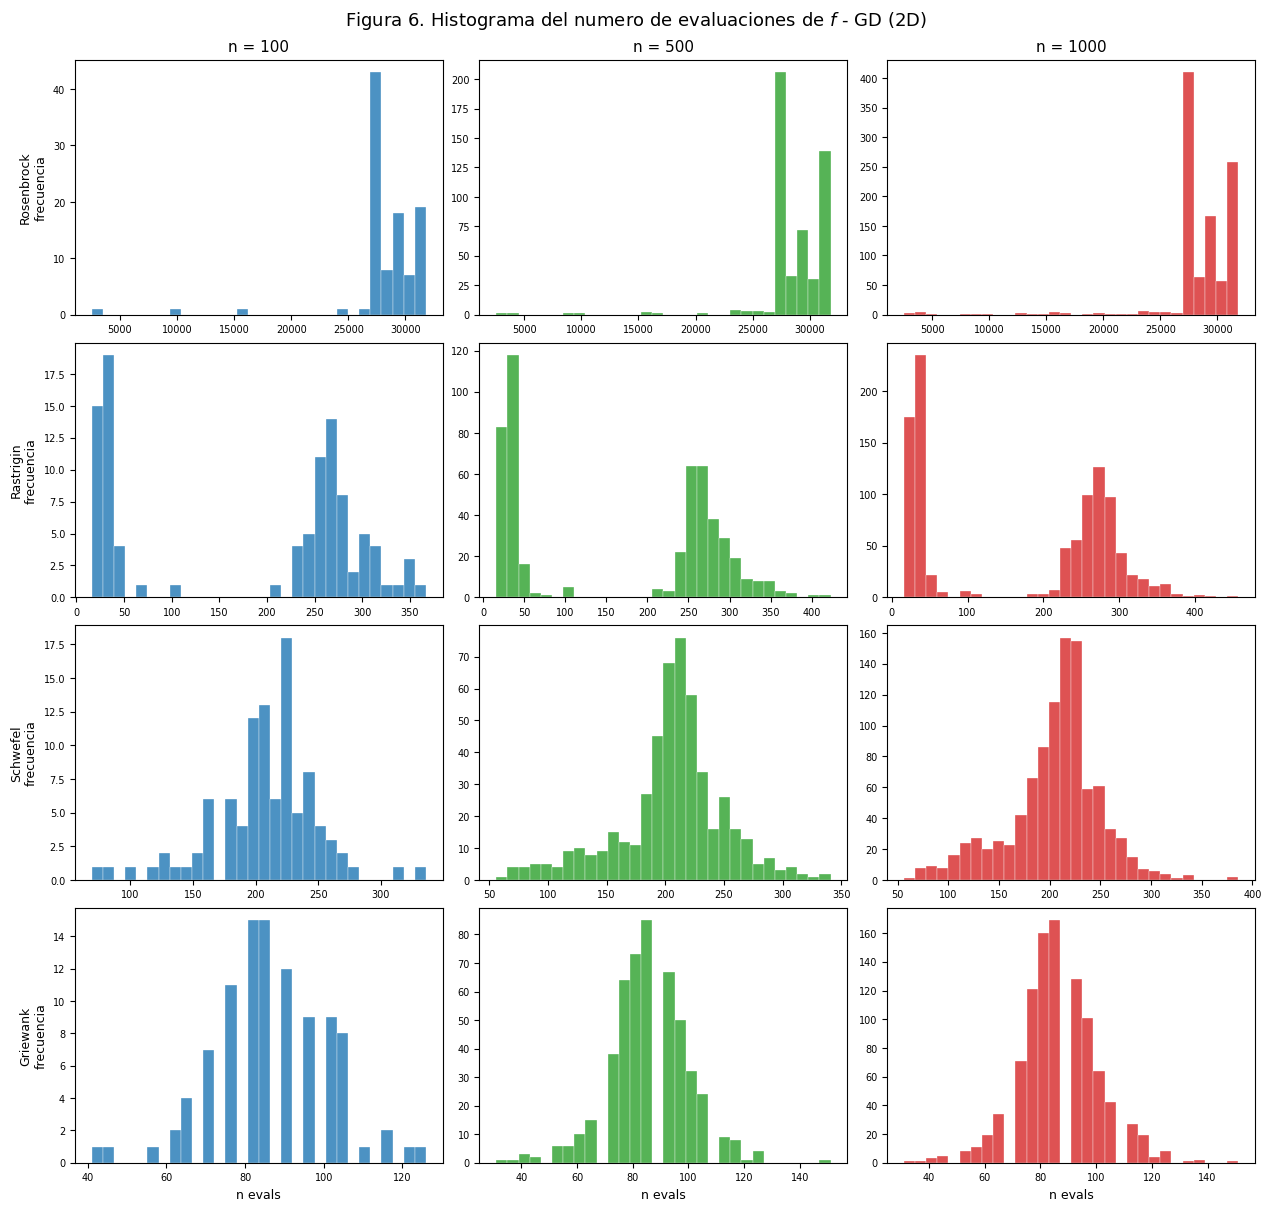

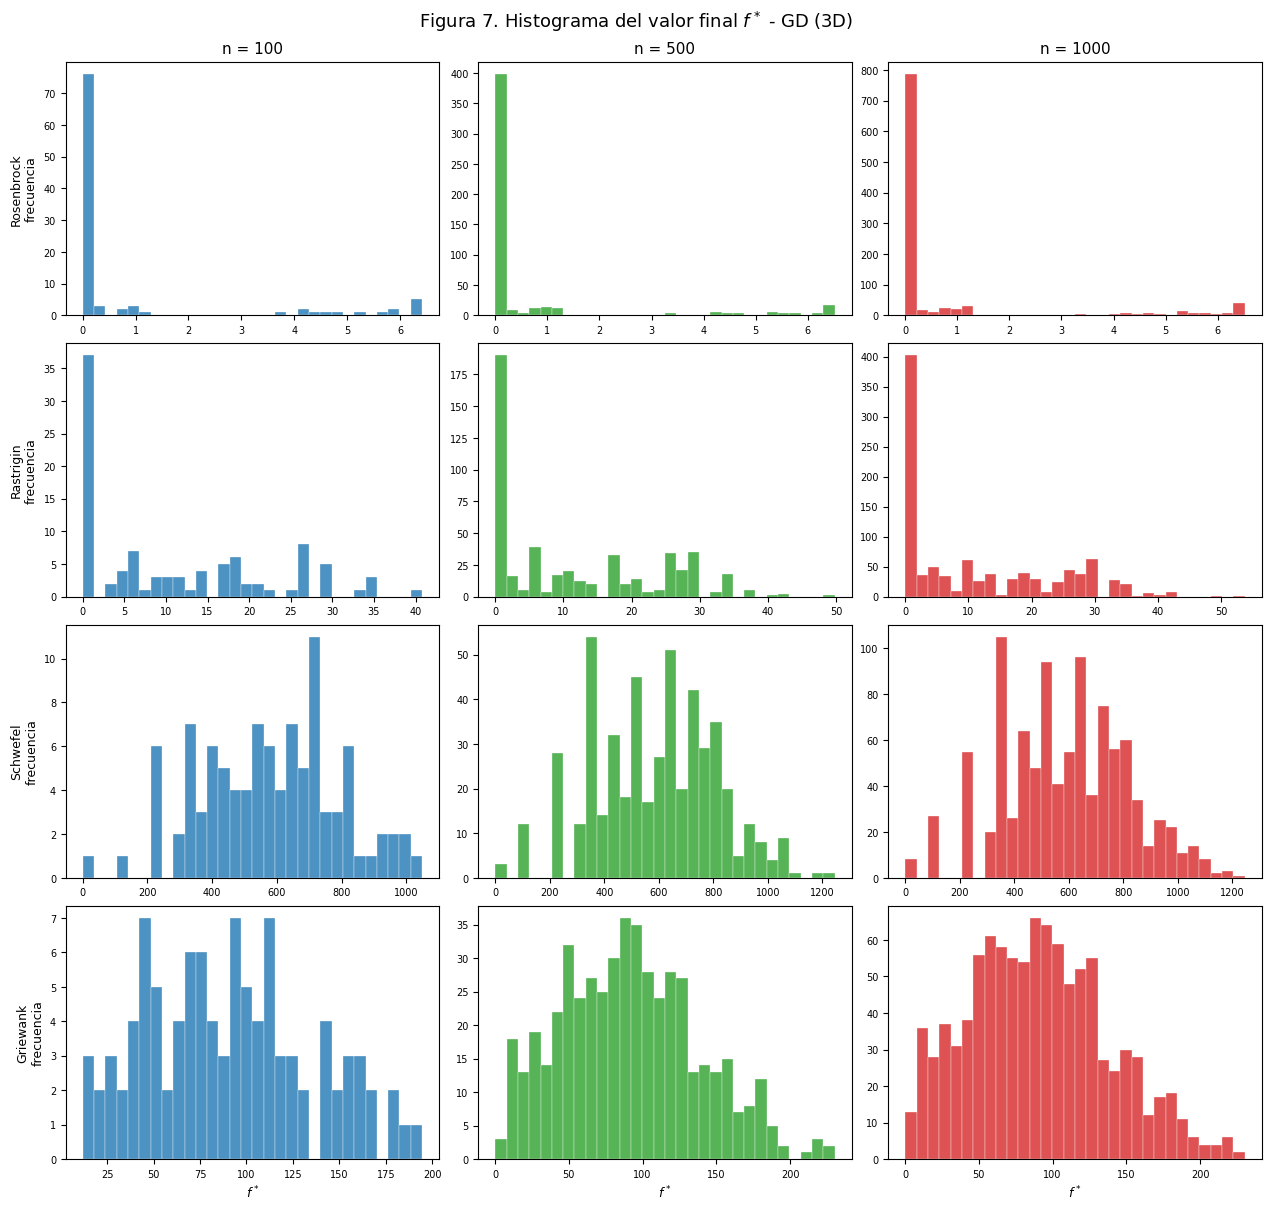

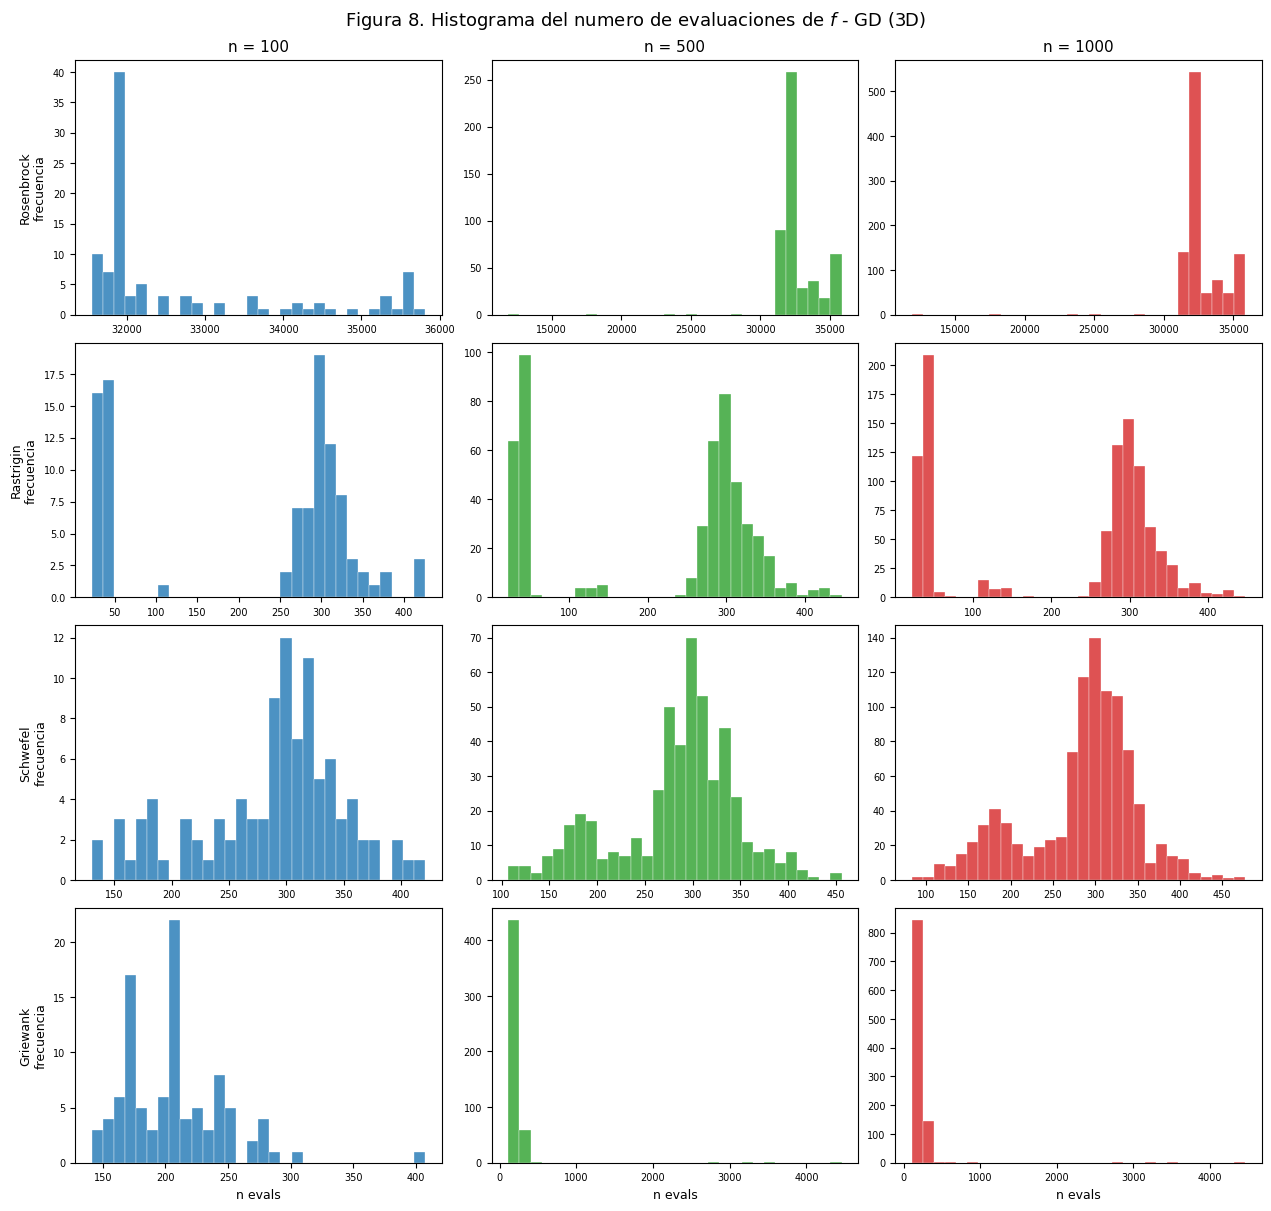

In [13]:
# ---------------------------------------------------------------------------
# Histogramas del valor final f* y del numero de evaluaciones de f, para
# n = 100/500/1000, en 2D y 3D. Se dibujan desde `resultados_stat` (en memoria).
# ---------------------------------------------------------------------------
colores_n = {100: '#1f77b4', 500: '#2ca02c', 1000: '#d62728'}
funcs = [c[0] for c in CONFIGS_ND]


def _hist_gd(ndim, clave, fignum, etiqueta):
    fig, axes = plt.subplots(len(funcs), len(N_REPS_LIST),
                             figsize=(4.2 * len(N_REPS_LIST), 3.0 * len(funcs)),
                             constrained_layout=True)
    fig.suptitle(f'Figura {fignum}. Histograma del {etiqueta} - GD ({ndim}D)', fontsize=13)
    for r, nombre in enumerate(funcs):
        for c, n_reps in enumerate(N_REPS_LIST):
            ax = axes[r][c]
            ax.hist(resultados_stat[nombre][ndim][n_reps][clave], bins=30,
                    color=colores_n[n_reps], alpha=0.8, edgecolor='white', linewidth=0.3)
            if c == 0:
                ax.set_ylabel(f'{nombre}\nfrecuencia', fontsize=9)
            if r == 0:
                ax.set_title(f'n = {n_reps}', fontsize=11)
            if r == len(funcs) - 1:
                ax.set_xlabel('$f^*$' if clave == 'f_vals' else 'n evals', fontsize=9)
            ax.tick_params(labelsize=7)
    slug = 'fstar' if clave == 'f_vals' else 'evals'
    plt.savefig(f'outputs/hist_gd_{slug}_{ndim}d.png', dpi=120, bbox_inches='tight')
    plt.show()


_hist_gd(2, 'f_vals', 5, 'valor final $f^*$')
_hist_gd(2, 'evals',  6, 'numero de evaluaciones de $f$')
_hist_gd(3, 'f_vals', 7, 'valor final $f^*$')
_hist_gd(3, 'evals',  8, 'numero de evaluaciones de $f$')

## 4. Animaciones GIF

Se anima la trayectoria del descenso por gradiente sobre el contour plot 2D.
Cada frame muestra la posición actual y la ruta recorrida hasta ese momento.

Se genera un **GIF por funcion** (6 en total) mostrando la trayectoria sobre el contour 2D.

Guardado: outputs/gd_rosenbrock_2d.gif  (636 KB)


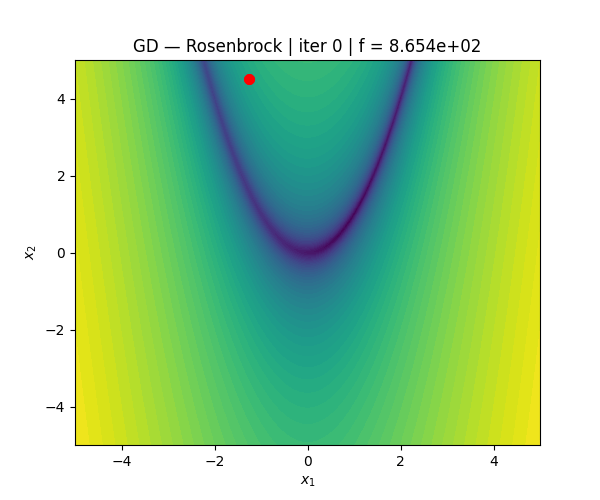

In [14]:
def animar_descenso(f, nombre, seed=SEED):
    """Genera GIF de la trayectoria del GD proyectado sobre el contour 2D."""
    np.random.seed(seed)
    lo, hi = BOUNDS_OPT_FUNC[nombre]
    res  = descenso_gradiente(f, np.random.uniform(lo, hi, 2), lo, hi)
    tray = res['trayectoria']
    hist = res['historial_f']

    X, Y, Z = grids[nombre]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.contourf(X, Y, np.log1p(Z), levels=60, cmap='viridis')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    linea,  = ax.plot([], [], 'w-', lw=1.5, alpha=0.85)
    punto,  = ax.plot([], [], 'ro', ms=7)
    titulo  = ax.set_title('')
    indices = np.linspace(0, len(tray) - 1, min(GIF_FRAMES, len(tray)), dtype=int)

    def actualizar(k):
        idx = indices[k]
        linea.set_data(tray[:idx+1, 0], tray[:idx+1, 1])
        punto.set_data([tray[idx, 0]], [tray[idx, 1]])
        titulo.set_text(f'GD — {nombre} | iter {idx} | f = {hist[min(idx, len(hist)-1)]:.3e}')
        return linea, punto, titulo

    ani = animation.FuncAnimation(
        fig, actualizar, frames=len(indices),
        init_func=lambda: (linea, punto, titulo), blit=True
    )
    ruta = 'outputs/gd_' + nombre.lower().replace(' ', '_') + '_2d.gif'
    ani.save(ruta, writer='pillow', fps=GIF_FPS)
    plt.close()
    print(f'Guardado: {ruta}  ({Path(ruta).stat().st_size // 1024} KB)')
    return ruta


# El enunciado pide animar un solo caso: usamos Rosenbrock 2D (valle estrecho),
# el mas ilustrativo del comportamiento del descenso por gradiente.
display(Image(animar_descenso(rosenbrock, 'Rosenbrock')))

## 5. Conclusiones

- **Rosenbrock:** el descenso por gradiente converge al mínimo global $f=0$ en 2D y 3D, pero requiere muchas iteraciones por el valle estrecho y curvado.

- **Rastrigin:** el gradiente queda atrapado en mínimos locales con alta frecuencia; el resultado depende fuertemente de la condición inicial. Esto motiva el uso de métodos heurísticos.

- **Costo computacional:** el número de evaluaciones es bajo para Rosenbrock (convergencia limpia), pero engañoso para Rastrigin, ya que el óptimo encontrado no es necesariamente el global.

> El análisis comparativo completo contra EA, PSO y DE se presenta en el **Notebook 02**.